In [1]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial
from scipy.interpolate import RBFInterpolator
from scipy.optimize import root_scalar
from collections import defaultdict

In [2]:
# Apply Savitzky-Golay filter
from scipy.signal import savgol_filter
window_length = 11  # Must be odd
polyorder = 3

In [3]:
# Constants
LAMBDA = 0.3

## Read the processed dataframes

In [4]:
experiment_data_df = pd.read_feather("experiment_data_df.feather")

In [5]:
experiment_data_df[experiment_data_df['active_servers_num'] > 700]['active_servers_num'].unique()

array([], dtype=int64)

In [6]:
experiment_data_df[experiment_data_df['run_iterations'] != 500]['run_iterations'].unique()

array([], dtype=int64)

In [7]:
experiment_data_df.columns

Index(['client_labda', 'server_mu', 'alpha', 'active_servers_num',
       'run_iterations', 'request_id', 'server_processing_time_ideal',
       'time_untill_next_client', 'sent_is_cpu', 'client_measured_time',
       'server_processing_time_measured', 'run_id'],
      dtype='str')

## Define the measuring fuctions for the project

In [51]:
import numpy as np
from typing import Sequence, Tuple
from sklearn.metrics import (
    mean_squared_error, 
    mean_absolute_error, 
    mean_absolute_percentage_error
)

def compare_results(y_true: Sequence[float], y_pred: Sequence[float]) -> Tuple[float, float, float]:
    """
    Calculate RMSE, MAE, and MAPE between ground truth and predictions.
    
    Parameters
    ----------
    y_true : array-like
        Ground truth (actual) values. Must not contain zeros for MAPE to be valid.
    y_pred : array-like
        Predicted values.
    
    Returns
    -------
    tuple of float
        (rmse, mae, mape) where mape is represented as a percentage (e.g., 5.0 for 5%).
    
    Raises
    ------
    ValueError
        If the vectors have different shapes, or if y_true contains zeros.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    
    if y_true.shape != y_pred.shape:
        raise ValueError(f"y_true and y_pred must have the same shape. Got {y_true.shape} and {y_pred.shape}.")
        
    # MAPE is undefined if actual values are zero. 
    # If your data has zeros, uncomment the line below to add a small epsilon to prevent division by zero.
    # y_true = np.where(y_true == 0, 1e-8, y_true)
    if np.any(y_true == 0):
        raise ValueError("y_true contains zeros. MAPE is undefined for zero actual values.")

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100  # Convert to percentage
    
    return rmse, mae, mape

def format_comparison(gathered_metrics: Tuple[float, float, float], decimals: int = 4) -> str:
    """
    Formats the metrics into a clean string suitable for a paper or log.
    
    Parameters
    ----------
    kpis : tuple
        A tuple containing (rmse, mae, mape).
    decimals : int, optional
        Number of decimal places to round to (default is 4).
        
    Returns
    -------
    str
        Formatted string of the metrics.
    """
    if len(gathered_metrics) != 3:
        raise ValueError("kpis must contain exactly 3 metrics: rmse, mae, and mape")

    rmse, mae, mape = gathered_metrics
    
    # Dynamically format to the requested decimal places
    fmt = f".{decimals}f"
    return f"RMSE: {rmse:{fmt}} | MAE: {mae:{fmt}} | MAPE: {mape:{fmt}}%"

def print_metrics_table(metrics, decimals=4):
    """
    Print a table of RMSE, MAE, MAPE per alpha, plus the overall average.

    Parameters
    ----------
    metrics : dict
        Dictionary with alpha as keys and (rmse, mae, mape) as values.
        Values can be np.nan if no predictions were available.
    decimals : int, optional
        Number of decimal places to display.
    """
    # Convert metrics dict to DataFrame
    df = pd.DataFrame.from_dict(metrics, orient='index',
                                columns=['RMSE', 'MAE', 'MAPE'])
    df.index.name = 'Alpha'
    
    # Compute averages, ignoring NaNs
    avg_rmse = np.nanmean(df['RMSE'])
    avg_mae  = np.nanmean(df['MAE'])
    avg_mape = np.nanmean(df['MAPE'])
    
    # Append average row
    avg_row = pd.DataFrame({'RMSE': avg_rmse, 'MAE': avg_mae, 'MAPE': avg_mape},
                           index=['Average'])
    
    df_with_avg = pd.concat([df, avg_row])
    
    # Format each column individually for robustness
    fmt = f"{{:.{decimals}f}}"
    df_formatted = df_with_avg.copy()
    for col in ['RMSE', 'MAE', 'MAPE']:
        df_formatted[col] = df_formatted[col].apply(
            lambda x: fmt.format(x) if not pd.isna(x) else 'N/A'
        )
    
    print("\n" + "="*60)
    print("MODEL PERFORMANCE METRICS PER α")
    print("="*60)
    print(df_formatted.to_string())
    print("="*60)
    print(f"Average RMSE: {avg_rmse:.{decimals}f}  |  Average MAE: {avg_mae:.{decimals}f}  |  Average MAPE: {avg_mape:.{decimals}f}%")
    print("="*60)

In [9]:
gathered_metrics1 = compare_results([1,1,1], [1,1,1])
format_comparison(gathered_metrics1)

'RMSE: 0.0000 | MAE: 0.0000 | MAPE: 0.0000%'

In [10]:
gathered_metrics2 = compare_results([0.1,0.1,0.1], [1,1,1])
format_comparison(gathered_metrics2)

'RMSE: 0.9000 | MAE: 0.9000 | MAPE: 900.0000%'

## Compare server_processing_time_measured to the client_measured_time

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from collections import defaultdict
import pickle

In [12]:
%%time
# -------- Estimate simple μ(n, α) --------
def estimate_mu_n_alpha_1(investigate_df):
    """
    Compute μ(n, α) = 1 / mean(server_processing_time_measured)
    using vectorized pandas operations.
    """
    # Ensure we have positive service times
    mask = investigate_df['server_processing_time_measured'] > 0
    # For aggregated data: directly invert the mean column
    # (If not aggregated, uncomment the groupby version below)
    mu_series = (1.0 / investigate_df.loc[mask].set_index(['active_servers_num', 'alpha'])['server_processing_time_measured'])
    return mu_series.to_dict()


cache_file_mu1 = "mu1.pkl"
try:
    with open(cache_file_mu1, 'rb') as fp:
        mu1 = pickle.load(fp)
except:
    # Compute service rate μ(n, α) from server_processing_time_measured
    mu1 = estimate_mu_n_alpha_1(experiment_data_df)
    with open(cache_file_mu1, 'wb') as fp:
        pickle.dump(mu1, fp)

CPU times: user 939 μs, sys: 984 μs, total: 1.92 ms
Wall time: 1.82 ms


In [13]:
# -------- Robust analitical M/M/n (no factorial) --------
def T_mmn(mu, lam, n):
    rho = lam / mu
    if rho >= n:
        return float('inf')
    A = 1.0
    sum_k = 0.0
    for k in range(n):
        sum_k += A
        A = A * rho / (k + 1)
    A_n = A
    term_n = A_n / (1.0 - rho / n)
    p0 = 1.0 / (sum_k + term_n)
    Lq = (rho * A_n) / (n * (1.0 - rho / n)**2) * p0
    L = Lq + rho
    return L / lam

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

def plot_all_alphas(experiment_data_df, mu_d,  lam=LAMBDA, n_min=21, n_max=694, figsize=(15, 10)):
    """
    Create 6 subplots (one per alpha) comparing empirical mean response time
    against the simple M/M/n prediction using the pure service rate.

    Parameters
    ----------
    experiment_data_df : pd.DataFrame
        Per‑request DataFrame with columns ['active_servers_num', 'alpha',
        'server_processing_time_measured'].
    mu_d: dict[(n, alpha): float]
        This is a precomputed simple service rate μ(n, α) dictionary
    lam : float, optional
        Arrival rate (default 0.3).
    n_min, n_max : int, optional
        Range of n to consider (default 21‑694).
    figsize : tuple, optional
        Figure size.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The generated figure.
    metrics : dict
        Dictionary with alpha as keys and (RMSE, MAE, MAPE) as values.
    """
    # 2. Define alpha values
    alphas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    
    # 3. Prepare subplots
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()
    
    all_metrics = {}   # Store metrics per alpha
    avg_rmse, avg_mae, avg_mape = [], [], []

    for idx, alpha in enumerate(alphas):
        ax = axes[idx]
        
        # 3a. Empirical mean per n for this alpha
        df_alpha = experiment_data_df[experiment_data_df['alpha'] == alpha]
        emp_means = df_alpha.groupby('active_servers_num')['client_measured_time'].mean()
        emp_means = emp_means[(emp_means.index >= n_min) & (emp_means.index <= n_max)]
        
        # 3b. Predictions for the same n values
        n_values = []
        pred_T = []
        for n in emp_means.index:
            mu = mu_d.get((n, alpha))
            if mu is not None and not np.isnan(mu):
                try:
                    T_pred = T_mmn(mu, lam, n)
                    if not np.isinf(T_pred):
                        n_values.append(n)
                        pred_T.append(T_pred)
                except Exception:
                    continue
        
        # 3c. Plot empirical and predicted
        ax.plot(emp_means.index, emp_means.values, 'ko-', label='Empirical', markersize=2)
        if n_values:
            ax.plot(n_values, pred_T, 'b-s', label='Simple M/M/n (pure service)', markersize=1.5, alpha=0.7)
        
        ax.set_xlabel('Number of servers (n)')
        ax.set_ylabel('Mean response time (s)')
        ax.set_title(f'α = {alpha}')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=8)
        ax.set_xlim(n_min, n_max)
        
        # 3d. Compute metrics if we have predictions
        if n_values:
            # Align empirical values to the same n as predictions
            y_true = [emp_means.loc[n] for n in n_values]
            y_pred = pred_T
            try:
                rmse, mae, mape = compare_results(y_true, y_pred)
                all_metrics[alpha] = (rmse, mae, mape)
                avg_rmse.append(rmse)
                avg_mae.append(mae)
                avg_mape.append(mape)
                metrics_str = format_comparison((rmse, mae, mape), decimals=4)
            except Exception as e:
                metrics_str = f"Metrics error: {e}"
        else:
            metrics_str = "No predictions available"
            all_metrics[alpha] = (np.nan, np.nan, np.nan)
        
        # Add metrics text to the subplot (top‑left corner)
        ax.text(0.02, 0.98, metrics_str, transform=ax.transAxes,
                verticalalignment='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # 4. Average metrics across alphas (ignore NaNs)
    if avg_rmse:
        avg_rmse_val = np.nanmean(avg_rmse)
        avg_mae_val = np.nanmean(avg_mae)
        avg_mape_val = np.nanmean(avg_mape)
        avg_str = format_comparison((avg_rmse_val, avg_mae_val, avg_mape_val), decimals=4)
        fig.suptitle(f'Average metrics across all α: {avg_str}', fontsize=14)
        print(f"Average metrics: {avg_str}")
    else:
        fig.suptitle('No predictions available for any alpha', fontsize=14)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Make room for suptitle
    return fig, all_metrics

Average metrics: RMSE: 1.0195 | MAE: 0.7446 | MAPE: 67.5920%


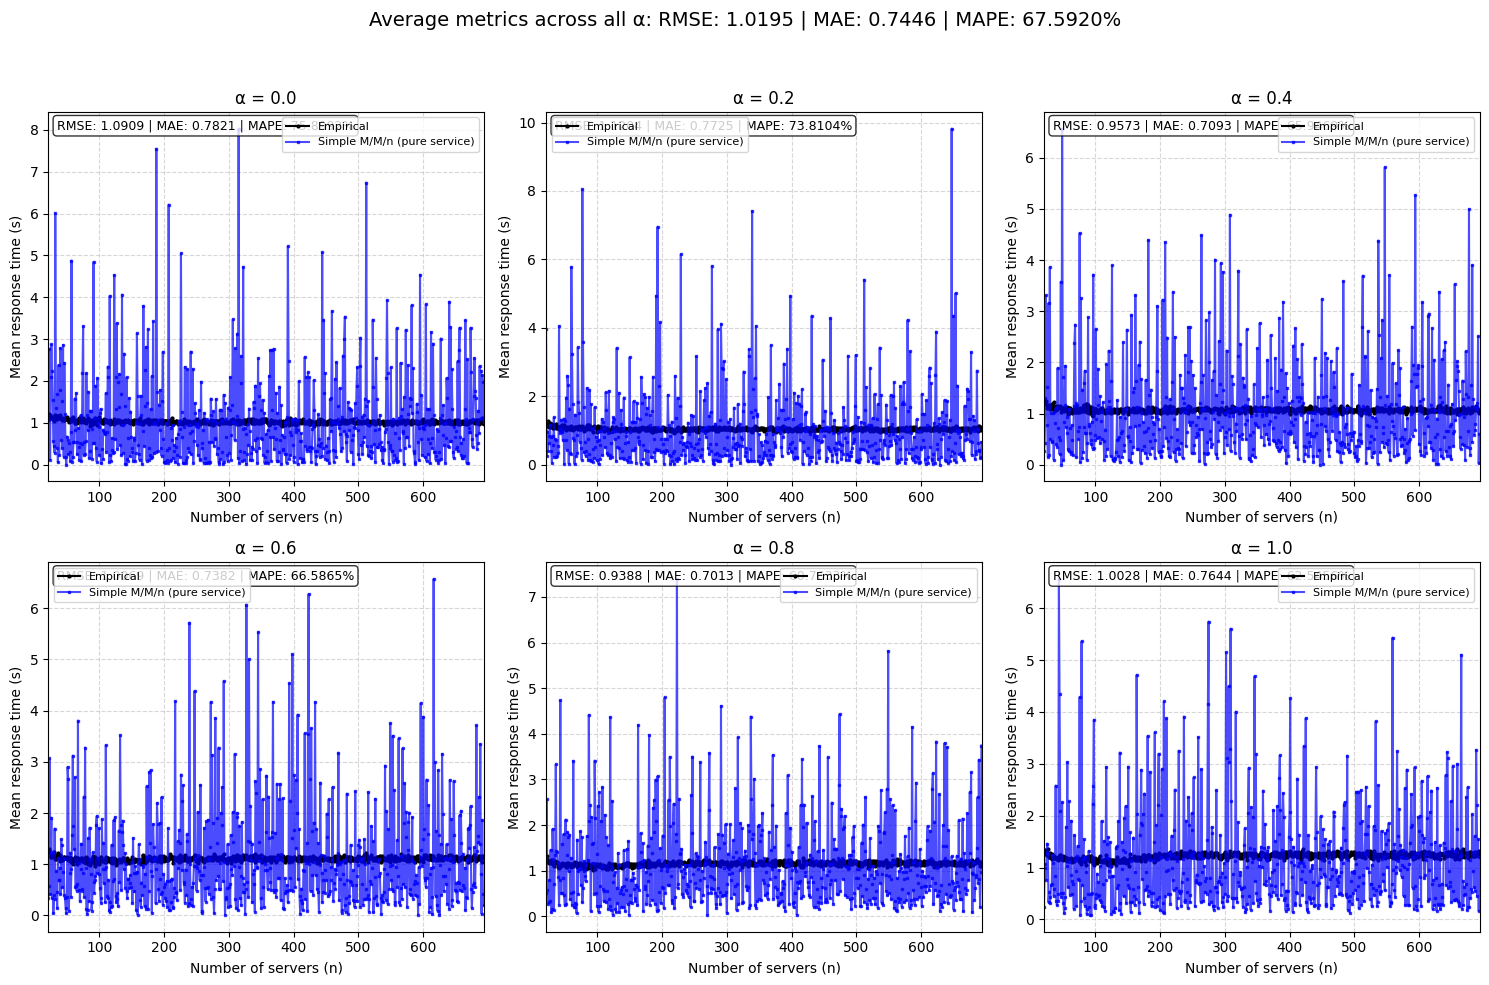


MODEL PERFORMANCE METRICS PER α
           RMSE     MAE     MAPE
0.0      1.0909  0.7821  75.8992
0.2      1.1204  0.7725  73.8104
0.4      0.9573  0.7093  65.9469
0.6      1.0069  0.7382  66.5865
0.8      0.9388  0.7013  60.7633
1.0      1.0028  0.7644  62.5456
Average  1.0195  0.7446  67.5920
Average RMSE: 1.0195  |  Average MAE: 0.7446  |  Average MAPE: 67.5920%


In [43]:
# Assuming state_df and investigate_df are already defined
fig, metrics = plot_all_alphas(experiment_data_df, mu_d=mu1, lam=LAMBDA, n_min=21, n_max=694)
plt.show()
# Optionally save
fig.savefig('naive_mu_prediction.png', dpi=300, bbox_inches='tight')

print_metrics_table(metrics, decimals=4)

In [17]:
import heapq
import numpy as np

def process_group(group):
    """
    Process one run group (DataFrame) and compute the state i for each request.
    Returns a list of tuples: (n, alpha, i, client_measured_time, server_processing_time_measured).
    """
    # Extract n and alpha from the group (they are constant within a group)
    n = group['active_servers_num'].iloc[0]
    alpha = group['alpha'].iloc[0]
    
    # Sort by request_id to ensure chronological order
    group = group.sort_values('request_id').reset_index(drop=True)
    
    # Convert relevant columns to numpy arrays for speed
    time_until_next = group['time_untill_next_client'].values
    client_measured = group['client_measured_time'].values
    server_processing = group['server_processing_time_measured'].values
    
    # Compute arrival times: first at t=0, then cumulative sum of inter-arrival times
    arrival_times = np.zeros(len(group))
    if len(group) > 1:
        arrival_times[1:] = np.cumsum(time_until_next[:-1])
    
    # Departure times = arrival + total round‑trip time
    departure_times = arrival_times + client_measured
    
    # Min‑heap to track active departures (maintains earliest departure at top)
    heap = []
    states = []
    
    for k, t_arr in enumerate(arrival_times):
        # Remove all departures that happened before or at this arrival
        while heap and heap[0] <= t_arr:
            heapq.heappop(heap)
        
        # Number of active previous requests = heap size
        active_before = len(heap)
        i = active_before + 1   # total in system after this request joins
        
        # Store the state information
        states.append((n, alpha, i, client_measured[k], server_processing[k]))
        
        # Push current departure time into the heap for future arrivals
        heapq.heappush(heap, departure_times[k])
    
    return states

In [18]:
all_states = []
for (alpha, n, run), group in experiment_data_df.groupby(['alpha', 'active_servers_num', 'run_id']):
    all_states.extend(process_group(group))

# Convert to DataFrame
state_df = pd.DataFrame(all_states, columns=['n', 'alpha', 'i', 'client_measured_time', 'server_processing_time_measured'])

In [19]:
all_states[0]

(np.int64(21), np.float64(0.0), 1, np.float64(0.68), np.float64(0.674295))

In [20]:
# --- Aggregate by (n, alpha, i) to get mean times and counts ---
agg = state_df.groupby(['n', 'alpha', 'i']).agg(
    T_emp=('client_measured_time', 'mean'),
    S_emp=('server_processing_time_measured', 'mean'),
    count=('client_measured_time', 'size')
).reset_index()

In [21]:
agg.head()

,n,alpha,i,T_emp,S_emp,count
0,21,0.0,1,1.041500,1.037310,28
1,21,0.0,2,1.032021,0.967580,96
2,21,0.0,3,0.973136,0.876569,169
3,21,0.0,4,1.160276,0.991703,185
4,21,0.0,5,1.080995,0.900503,187


In [22]:
# --- Calculate effective μ and pure μ ---
results = []

for _, row in agg.iterrows():
    n = int(row['n'])
    alpha = row['alpha']
    i = int(row['i'])
    T_emp = row['T_emp']
    S_emp = row['S_emp']
    count = row['count']
    
    # Pure service rate (from server processing time)
    mu_pure = 1.0 / S_emp if S_emp > 0 else np.nan
    
    # Effective service rate (from total round time)
    if i <= n:
        # No queue: T_emp = 1 / mu_eff
        mu_eff = 1.0 / T_emp if T_emp > 0 else np.nan
    else:
        # Queue: T_emp = i / (n * mu_eff)   (corrected formula)
        mu_eff = i / (n * T_emp) if T_emp > 0 else np.nan
    
    service_time_eff = 1.0 / mu_eff if not np.isnan(mu_eff) else np.nan
    service_time_pure = 1.0 / mu_pure if not np.isnan(mu_pure) else np.nan
    overhead = service_time_eff - service_time_pure if not np.isnan(service_time_eff) and not np.isnan(service_time_pure) else np.nan
    
    results.append({
        'n': n,
        'alpha': alpha,
        'i': i,
        'count': count,
        'mu_pure': mu_pure,
        'mu_eff': mu_eff,
        'service_time_pure (s)': service_time_pure,
        'service_time_eff (s)': service_time_eff,
        'overhead_per_request (s)': overhead
    })

results_df = pd.DataFrame(results)

In [23]:
results_df.head()

,n,alpha,i,count,mu_pure,mu_eff,service_time_pure (s),service_time_eff (s),overhead_per_request (s)
0,21,0.0,1,28.0,0.964032,0.960154,1.037310,1.041500,0.004190
1,21,0.0,2,96.0,1.033507,0.968973,0.967580,1.032021,0.064441
2,21,0.0,3,169.0,1.140811,1.027605,0.876569,0.973136,0.096567
3,21,0.0,4,185.0,1.008366,0.861864,0.991703,1.160276,0.168572
4,21,0.0,5,187.0,1.110490,0.925074,0.900503,1.080995,0.180492


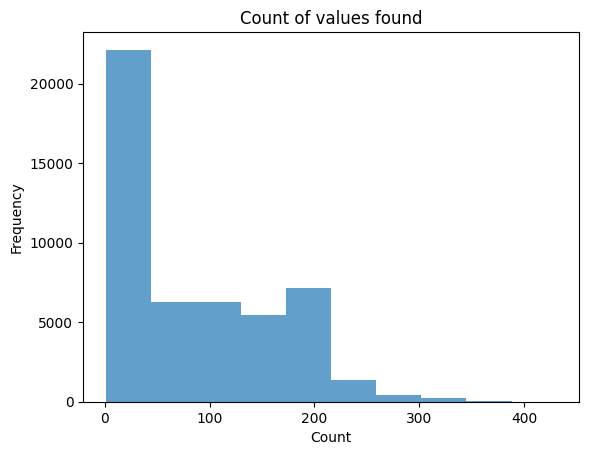

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

results_df['count'].plot(kind='hist', alpha=0.7)

# Step 3: Show the plot
plt.title('Count of values found')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.show()


<Axes: ylabel='Frequency'>

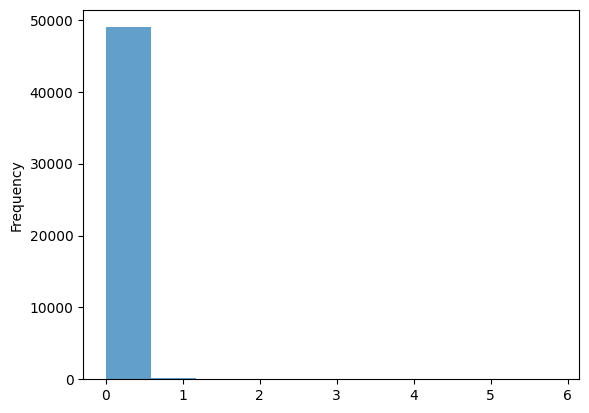

In [25]:
results_df["overhead_per_request (s)"].plot(kind='hist', alpha=0.7)

In [26]:
results_df[results_df["overhead_per_request (s)"] < 0]

,n,alpha,i,count,mu_pure,mu_eff,service_time_pure (s),service_time_eff (s),overhead_per_request (s)


In [27]:
results_df[results_df["overhead_per_request (s)"] > 0]

,n,alpha,i,count,mu_pure,mu_eff,service_time_pure (s),service_time_eff (s),overhead_per_request (s)
0,21,0.0,1,28.0,0.964032,0.960154,1.037310,1.041500,0.004190
1,21,0.0,2,96.0,1.033507,0.968973,0.967580,1.032021,0.064441
2,21,0.0,3,169.0,1.140811,1.027605,0.876569,0.973136,0.096567
3,21,0.0,4,185.0,1.008366,0.861864,0.991703,1.160276,0.168572
4,21,0.0,5,187.0,1.110490,0.925074,0.900503,1.080995,0.180492
...,...,...,...,...,...,...,...,...,...
49309,693,1.0,10,25.0,0.889626,0.884236,1.124067,1.130920,0.006853
49310,693,1.0,11,14.0,0.539239,0.473437,1.854465,2.112214,0.257749
49311,693,1.0,12,6.0,0.599755,0.596481,1.667347,1.676500,0.009153
49312,693,1.0,13,5.0,0.633780,0.631074,1.577834,1.584600,0.006766


## Use differnent methods to estimate via M/M/n model

In [28]:
%%time
from scipy.optimize import brentq
import numpy as np
from multiprocessing import Pool, cpu_count
import pandas as pd
import pickle

def _worker_n(n, df_subset, lam, mu_bounds, fallback):
    """Process all rows for a single n, return mu_dict for that n."""
    mu_low = max(mu_bounds[0], lam / n * 1.001)
    mu_high = mu_bounds[1]
    T_low = T_mmn(mu_low, lam, n)
    T_high = T_mmn(mu_high, lam, n)
    
    local_dict = {}
    for _, row in df_subset.iterrows():  # can use itertuples for speed
        alpha = row['alpha']
        T_target = row['client_measured_time']
        f_low = T_low - T_target
        f_high = T_high - T_target
        
        if np.isinf(f_low) or np.isinf(f_high) or f_low * f_high >= 0:
            local_dict[(n, alpha)] = fallback.get((n, alpha), np.nan)
        else:
            try:
                mu = brentq(lambda mu: T_mmn(mu, lam, n) - T_target, mu_low, mu_high)
                local_dict[(n, alpha)] = mu
            except Exception:
                local_dict[(n, alpha)] = fallback.get((n, alpha), np.nan)
    return local_dict

def estimate_mu_n_alpha_2_parallel(investigate_df, lam=0.3, mu_bounds=(0.01, 20.0), n_workers=None):
    """
    Parallel version of estimate_mu_n_alpha_2.
    Splits work by unique n and processes each in a separate process.
    """
    fallback = estimate_mu_n_alpha_1(investigate_df)
    
    # Group by n to create chunks
    grouped = investigate_df.groupby('active_servers_num')
    n_groups = [(n, group) for n, group in grouped]
    
    if n_workers is None:
        n_workers = cpu_count()
    
    with Pool(processes=n_workers) as pool:
        # Prepare arguments for each chunk: (n, df_subset, lam, mu_bounds, fallback)
        args = [(n, df, lam, mu_bounds, fallback) for n, df in n_groups]
        results = pool.starmap(_worker_n, args)
    
    # Merge dictionaries
    mu_dict = {}
    for d in results:
        mu_dict.update(d)
    return mu_dict

"""
The function estimate_mu_n_alpha_2 implements calibration of a single constant service rate μ(n,α)
    for each configuration (n,α) by inverting the standard M/M/n (Erlang‑C) formula. 
The goal is to find a service rate such that the theoretical mean response time exactly matches the 
    empirically observed mean total round time Temp (from client_measured_time). 
This is a widely used technique in queueing theory when one wants to "reverse‑engineer" the service rate 
    from observed performance, under the assumption that the system behaves like an M/M/n queue.
"""
cache_file_mu2 = "mu2.pkl"
try:
    with open(cache_file_mu2, 'rb') as fp:
        mu2 = pickle.load(fp)
except:
    mu2 = estimate_mu_n_alpha_2_parallel(experiment_data_df, lam=LAMBDA, n_workers=10)
    with open(cache_file_mu2, 'wb') as fp:
        pickle.dump(mu2, fp)

CPU times: user 947 μs, sys: 3.91 ms, total: 4.86 ms
Wall time: 3.8 ms


Average metrics: RMSE: 1.0378 | MAE: 0.7532 | MAPE: 68.3647%


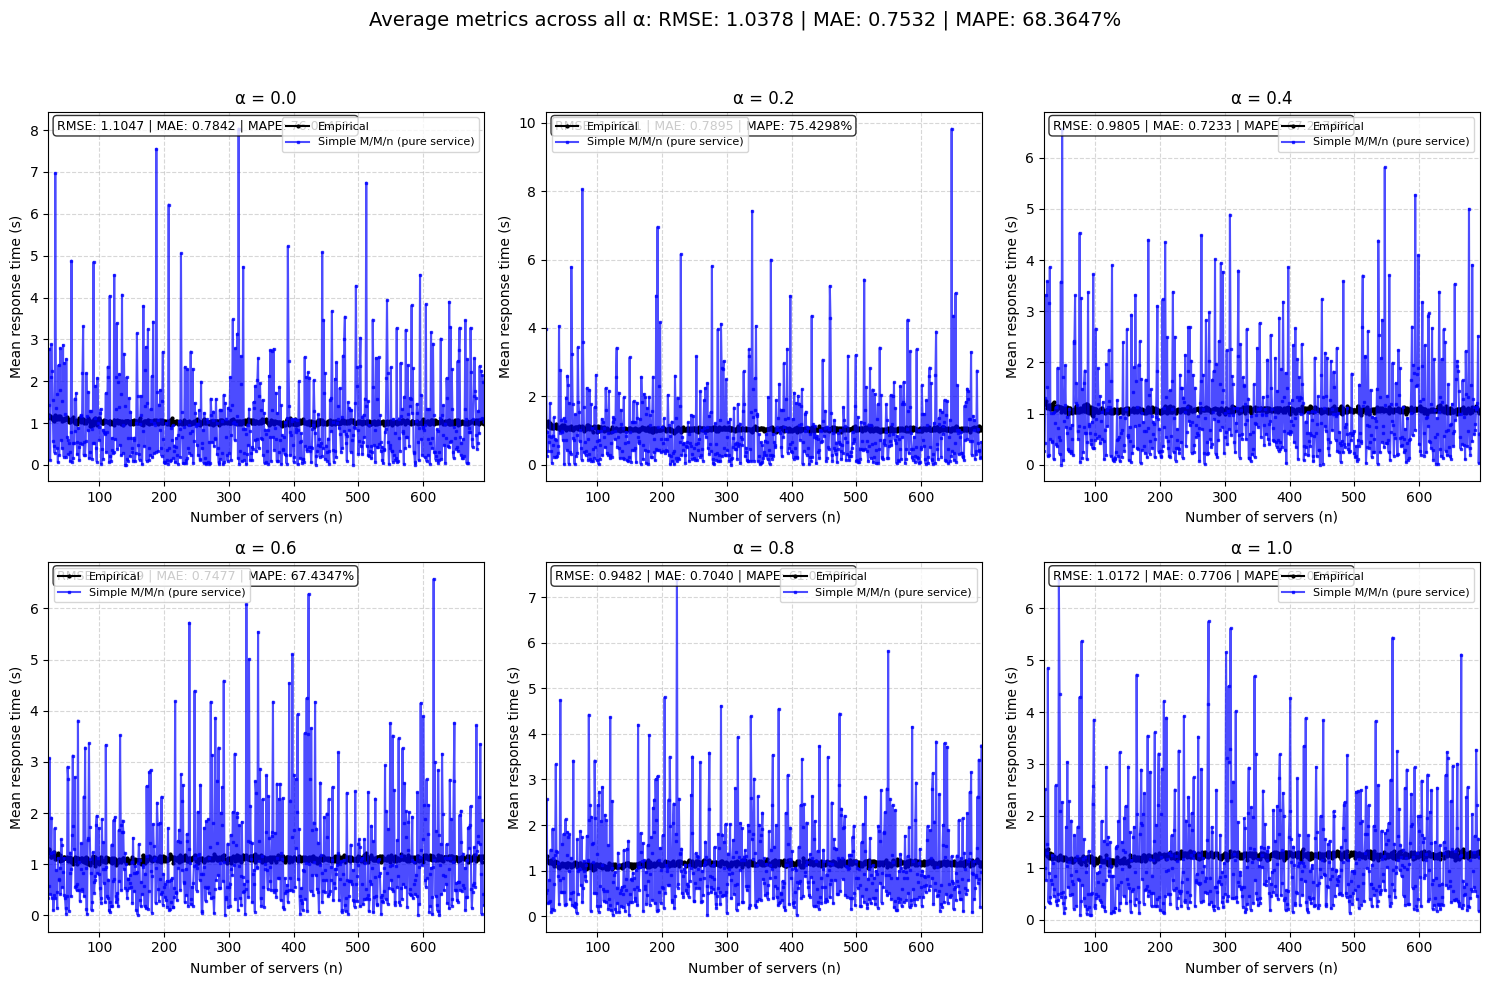


MODEL PERFORMANCE METRICS PER α
           RMSE     MAE     MAPE
0.0      1.1047  0.7842  76.0845
0.2      1.1521  0.7895  75.4298
0.4      0.9805  0.7233  67.2174
0.6      1.0239  0.7477  67.4347
0.8      0.9482  0.7040  61.0170
1.0      1.0172  0.7706  63.0047
Average  1.0378  0.7532  68.3647
Average RMSE: 1.0378  |  Average MAE: 0.7532  |  Average MAPE: 68.3647%


In [29]:
# Assuming state_df and investigate_df are already defined
fig, metrics = plot_all_alphas(experiment_data_df, mu_d=mu2, lam=LAMBDA, n_min=21, n_max=694)
plt.show()
# Optionally save
# fig.savefig('comparison_all_alphas.png', dpi=300, bbox_inches='tight')

print_metrics_table(metrics, decimals=4)

In [30]:
def estimate_mu_low_load(state_df):
    """
    Compute μ(n, α) from the mean client_measured_time for requests
    that experienced no queue (i < n).

    Parameters
    ----------
    state_df : pd.DataFrame
        Per‑request DataFrame with columns: n, alpha, i, client_measured_time.
        Must contain the state i for each request.

    Returns
    -------
    dict
        Keys: (n, alpha)  →  value: service rate = 1 / mean(total_time).
    """
    low_load = state_df[state_df['i'] < state_df['n']]
    # Compute mean total time per (n, alpha)
    mean_times = low_load.groupby(['n', 'alpha'])['mu_eff'].mean()
    # Invert to get service rate
    mu_dict = {(n, alpha): t for (n, alpha), t in mean_times.items() if t > 0}
    return mu_dict

Average metrics: RMSE: 0.1726 | MAE: 0.1122 | MAPE: 10.3131%


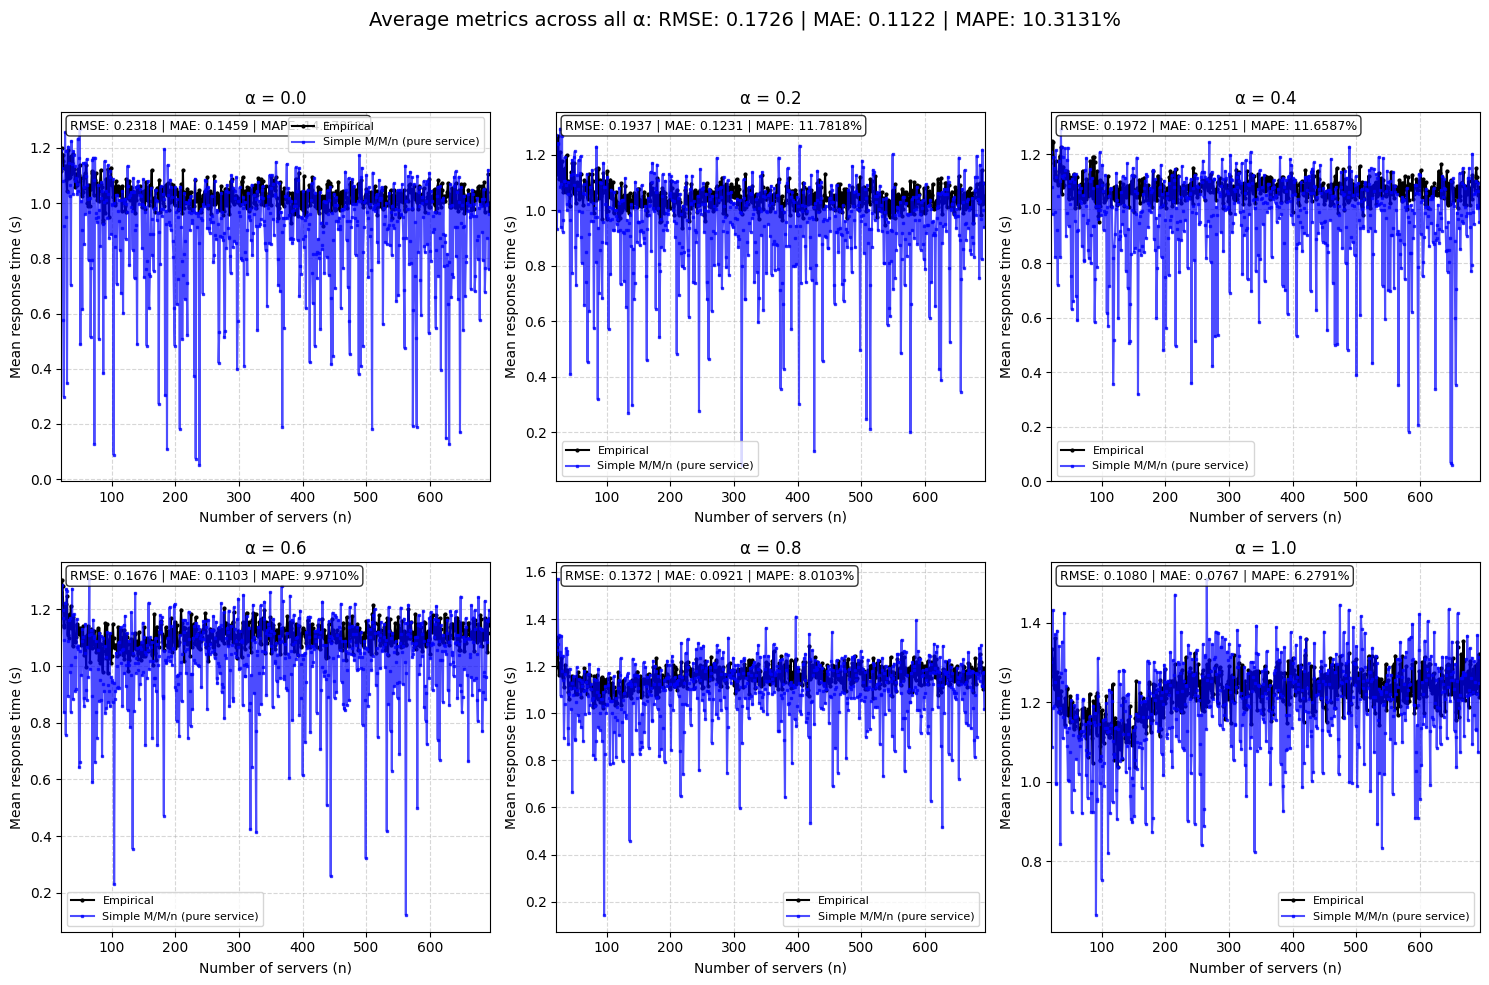


MODEL PERFORMANCE METRICS PER α
           RMSE     MAE     MAPE
0.0      0.2318  0.1459  14.1781
0.2      0.1937  0.1231  11.7818
0.4      0.1972  0.1251  11.6587
0.6      0.1676  0.1103   9.9710
0.8      0.1372  0.0921   8.0103
1.0      0.1080  0.0767   6.2791
Average  0.1726  0.1122  10.3131
Average RMSE: 0.1726  |  Average MAE: 0.1122  |  Average MAPE: 10.3131%


In [31]:
mu_low = estimate_mu_low_load(results_df)
fig, metrics = plot_all_alphas(experiment_data_df, mu_d=mu_low, lam=LAMBDA, n_min=21, n_max=694)
plt.show()

print_metrics_table(metrics, decimals=4)

In [32]:
def estimate_mu_weighted_average(results_df):
    """
    Compute μ(n, α) as a weighted average of state‑dependent μ_eff,
    where weights are the observed frequencies of each state i.

    Parameters
    ----------
    results_df : pd.DataFrame
        DataFrame with columns: n, alpha, i, count, mu_eff.
        Typically the output from the state‑dependent processing.

    Returns
    -------
    dict
        Keys: (n, alpha)  →  value: weighted average service rate.
    """
    # Total count per (n, alpha)
    total_counts = results_df.groupby(['n', 'alpha'])['count'].sum().reset_index(name='total')
    merged = results_df.merge(total_counts, on=['n', 'alpha'])
    merged['weight'] = merged['count'] / merged['total']
    merged['weighted_mu'] = merged['mu_eff'] * merged['weight']
    
    # Aggregate to get weighted average per (n, alpha)
    weighted_avg = merged.groupby(['n', 'alpha'])['weighted_mu'].sum().reset_index()
    
    # Convert to dict
    mu_dict = {(row['n'], row['alpha']): row['weighted_mu'] for _, row in weighted_avg.iterrows()}
    return mu_dict

Average metrics: RMSE: 0.0156 | MAE: 0.0123 | MAPE: 1.1185%


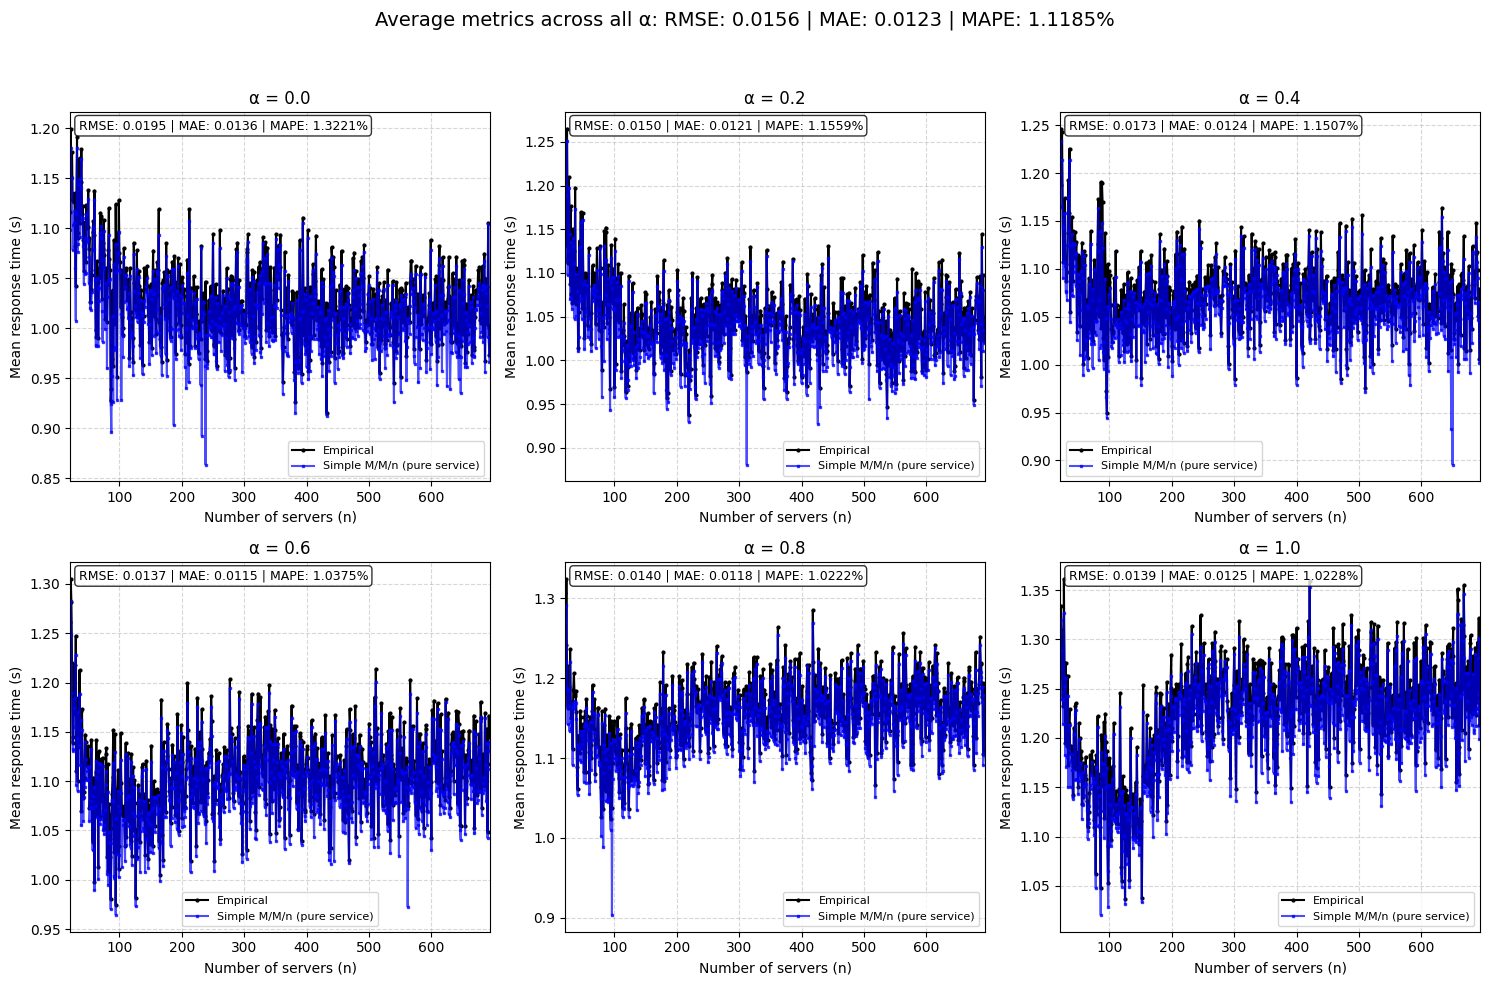


MODEL PERFORMANCE METRICS PER α
           RMSE     MAE    MAPE
0.0      0.0195  0.0136  1.3221
0.2      0.0150  0.0121  1.1559
0.4      0.0173  0.0124  1.1507
0.6      0.0137  0.0115  1.0375
0.8      0.0140  0.0118  1.0222
1.0      0.0139  0.0125  1.0228
Average  0.0156  0.0123  1.1185
Average RMSE: 0.0156  |  Average MAE: 0.0123  |  Average MAPE: 1.1185%


In [33]:
mu_weighted_avg = estimate_mu_weighted_average(results_df)
fig, metrics = plot_all_alphas(experiment_data_df, mu_d=mu_weighted_avg, lam=LAMBDA, n_min=21, n_max=694)
plt.show()

print_metrics_table(metrics, decimals=4)

In [34]:
import numpy as np
from scipy.optimize import curve_fit

def _power_law(n, a, b):
    return a * (n ** b)

def estimate_mu_parametric_fit(mu_avg_dict, n_range=None, fit_func=_power_law):
    """
    Fit a parametric function μ(n, α) to the given average service rates.

    Parameters
    ----------
    mu_avg_dict : dict
        Dictionary mapping (n, alpha) -> average service rate (e.g., from Option 1).
        Should contain at least 2 points per alpha for a meaningful fit.
    n_range : array‑like, optional
        If provided, predictions are made for these n values for each alpha.
        Otherwise, uses the observed n values.
    fit_func : callable, optional
        Function of the form f(n, *params). Default is power law: a * n^b.

    Returns
    -------
    dict
        Keys: (n, alpha)  →  value: predicted service rate from the fit.
    """
    # Group by alpha
    alpha_groups = {}
    for (n, alpha), mu in mu_avg_dict.items():
        alpha_groups.setdefault(alpha, []).append((n, mu))
    
    # If n_range not provided, use all observed n for each alpha (union)
    if n_range is None:
        all_n = sorted({n for (n, _) in mu_avg_dict.keys()})
        n_range = all_n
    else:
        n_range = sorted(n_range)
    
    mu_fitted = {}
    for alpha, points in alpha_groups.items():
        if len(points) < 2:
            # Not enough points to fit; fallback to the average of observed mu
            avg_mu = np.mean([mu for _, mu in points])
            for n in n_range:
                mu_fitted[(n, alpha)] = avg_mu
            continue
        
        ns, mus = zip(*points)
        ns = np.array(ns)
        mus = np.array(mus)
        
        # Fit the function
        try:
            popt, _ = curve_fit(fit_func, ns, mus, p0=[1.0, -0.5], maxfev=5000)
            # Predict for all n in n_range
            pred_mu = fit_func(np.array(n_range), *popt)
            # Clamp to avoid negative or zero
            pred_mu = np.maximum(0.01, pred_mu)
            for n, mu in zip(n_range, pred_mu):
                mu_fitted[(n, alpha)] = mu
        except Exception:
            # Fallback to the mean of observed mu
            avg_mu = np.mean(mus)
            for n in n_range:
                mu_fitted[(n, alpha)] = avg_mu
    
    return mu_fitted

Average metrics: RMSE: 0.0430 | MAE: 0.0335 | MAPE: 2.9912%


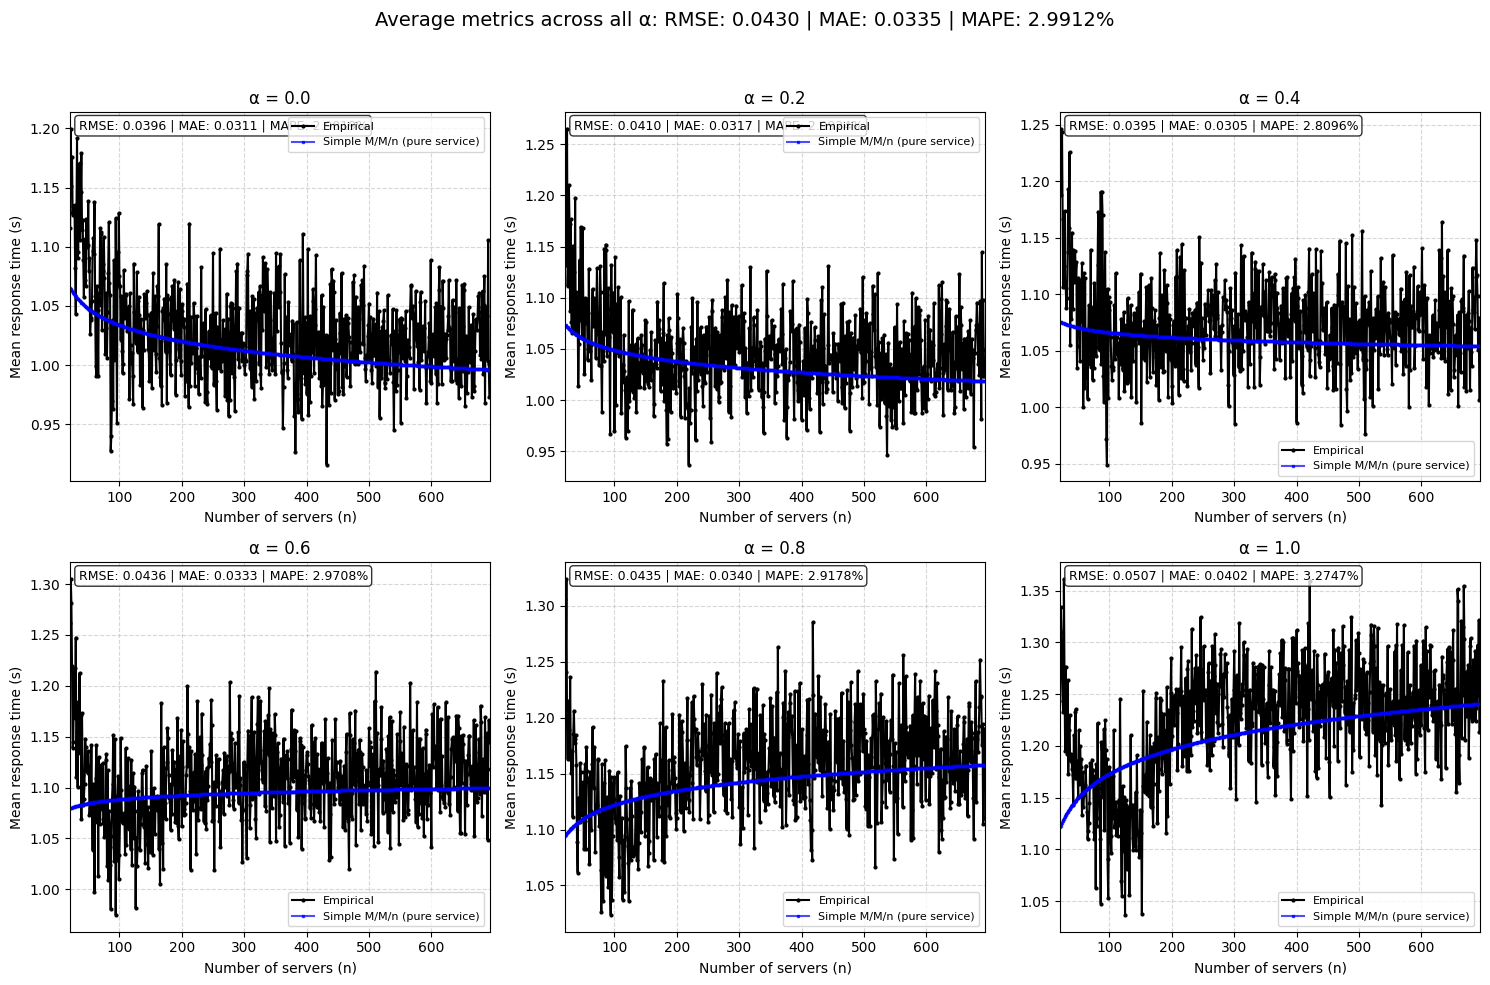


MODEL PERFORMANCE METRICS PER α
           RMSE     MAE    MAPE
0.0      0.0396  0.0311  2.9819
0.2      0.0410  0.0317  2.9924
0.4      0.0395  0.0305  2.8096
0.6      0.0436  0.0333  2.9708
0.8      0.0435  0.0340  2.9178
1.0      0.0507  0.0402  3.2747
Average  0.0430  0.0335  2.9912
Average RMSE: 0.0430  |  Average MAE: 0.0335  |  Average MAPE: 2.9912%


In [35]:
mu_parametric = estimate_mu_parametric_fit(mu_weighted_avg, n_range=range(21, 695))
fig, metrics = plot_all_alphas(experiment_data_df, mu_d=mu_parametric, lam=LAMBDA, n_min=21, n_max=694)
plt.show()

print_metrics_table(metrics, decimals=4)

In [44]:
def predict_T(n, alpha, lam, mu_n_alpha_i, fallback_mu_n_alpha=None):
    """
    Predict the mean total round time T for an M/M/n queue with state‑dependent
    service rates μ(n, α, i).  This function implements your exact formulas
    using numerically stable recurrences.

    Parameters
    ----------
    n : int
        Number of servers (containers).
    alpha : float
        The proportion of CPU‑bound requests.
    lam : float
        Arrival rate (λ).
    mu_n_alpha_i : dict
        Dictionary with keys (n, alpha, i) mapping to the effective service
        rate μ(n, α, i).  Must contain rates for i = 1 .. n, unless a fallback
        is provided.
    fallback_mu_n_alpha : dict, optional
        Dictionary with keys (n, alpha) mapping to a single constant service rate
        μ(n, α).  Used for any state i that is missing from mu_n_alpha_i.

    Returns
    -------
    T : float
        Mean response time (sojourn time) in the system, in seconds.

    Raises
    ------
    ValueError
        If a required μ cannot be found and no fallback is available, or if the
        system is unstable (n·μ(n,α,n) - λ ≤ 0).
    """
    # Helper to retrieve μ for a given state i.
    def get_mu(i):
        key = (n, alpha, i)
        if key in mu_n_alpha_i:
            return mu_n_alpha_i[key]
        if fallback_mu_n_alpha is not None:
            fb_key = (n, alpha)
            if fb_key in fallback_mu_n_alpha:
                return fallback_mu_n_alpha[fb_key]
        raise ValueError(f"Missing μ for n={n}, alpha={alpha}, i={i}")

    # Retrieve all required rates for i = 1 .. n
    mu_vals = [get_mu(i) for i in range(1, n+1)]

    # ------------------------------------------------------------------
    # 1.  Compute A_k = λ^k / ( k! * Π_{j=1}^k μ_j )  for k = 0..n
    #     using recurrence: A_0 = 1, A_k = A_{k-1} * λ / (k * μ_k)
    # ------------------------------------------------------------------
    A = 1.0               # A_0
    sum1 = 0.0            # Σ_{k=1}^{n} A_k
    sum_L1 = 0.0          # Σ_{k=1}^{n} k * A_k   (needed for L)

    for k in range(1, n+1):
        mu_k = mu_vals[k-1]
        A = A * lam / (k * mu_k)   # now A = A_k
        sum1 += A
        sum_L1 += k * A

    # After the loop, A == A_n
    A_n = A
    mu_n = mu_vals[n-1]   # μ(n, α, n)

    # ------------------------------------------------------------------
    # 2.  Stability condition: n * μ_n - λ must be > 0
    # ------------------------------------------------------------------
    denom = n * mu_n - lam
    if denom <= 0:
        raise ValueError(
            f"Unstable for n={n}, α={alpha}: n·μ_n - λ = {denom} ≤ 0. "
            "Increase servers or reduce load."
        )

    # ------------------------------------------------------------------
    # 3.  Compute p0 using the recurrence‑based expressions.
    #     The term for k = n+1 is  λ^(n+1) / ( n! * prod_n * (n μ_n - λ) )
    #     but λ^(n+1) / (n! * prod_n) = A_n * λ, so:
    # ------------------------------------------------------------------
    term_n1 = A_n * lam / denom
    p0 = 1.0 / (1.0 + sum1 + term_n1)

    # ------------------------------------------------------------------
    # 4.  Compute L (mean number in system) using the second part of your formula.
    #     L = [ Σ_{k=1}^n k A_k  +  extra ] * p0
    #     where extra =  λ^(n+1) / ((n-1)! prod_n) *
    #                    (1 + μ_n/(n μ_n - λ)) / (n μ_n - λ)
    #
    #     But λ^(n+1) / ((n-1)! prod_n) = n * λ * A_n, so:
    # ------------------------------------------------------------------
    factor = n * lam * A_n / denom
    term_L2 = factor * (1.0 + mu_n / denom)

    L = (sum_L1 + term_L2) * p0

    # ------------------------------------------------------------------
    # 5.  Little's Law: T = L / λ
    # ------------------------------------------------------------------
    T = L / lam
    return T

## "mu_n_alpha_i" and "mu_n_alpha" creation

In [46]:
mean_T_dict = state_df.groupby(['n', 'alpha'])['client_measured_time'].mean().to_dict()
mu_n_alpha = {k:(1/v) for k, v in mean_T_dict.items()}

In [70]:
# --- Output the dictionary mu_n_alpha_i for your model ---
mu_n_alpha_i = {}
filter_df = results_df['count'] > 30
for _, row in results_df[filter_df].iterrows():
    key = (row['n'], row['alpha'], row['i'])
    mu_n_alpha_i[key] = row['mu_eff']

In [48]:
mu_n_alpha2 = {}
filter_df = results_df['count'] > 30
for (n, alpha), group in results_df[filter_df].groupby(['n', 'alpha']):
    mu_n_alpha2[(n, alpha)] =  group['mu_eff'].mean()

In [49]:
mu_n_alpha3 = {}
for (alpha, n), group in experiment_data_df.groupby(['alpha', 'active_servers_num']):
    mu_n_alpha3[(n, alpha)] = 1 / group['client_measured_time'].mean()

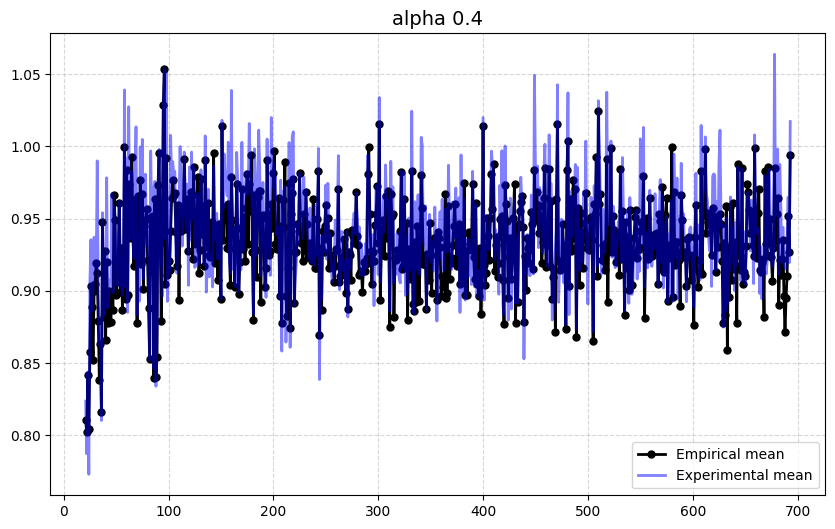

'RMSE: 0.0224 | MAE: 0.0173 | MAPE: 1.8612%'

In [56]:
alpha = 0.4
n_range = range(21, 694)

fig, ax = plt.subplots(figsize=(10, 6))

emp_mean1 = []
emp_mean2 = []
for n in n_range:
    # Empirical mean
    emp_mean1.append(mu_n_alpha[(n, alpha)])
    # Prediction
    emp_mean2.append(mu_n_alpha2[(n, alpha)])

df_alpha = state_df[state_df['alpha'] == alpha]
total_round_time_n_alpha = df_alpha.groupby('n')['client_measured_time'].mean()

ax.plot(n_range, emp_mean1, 'ko-', label='Empirical mean', markersize=5, linewidth=2)
ax.plot(n_range, emp_mean2, 'b-', label='Experimental mean', markersize=5, linewidth=2, alpha=0.5)

ax.set_title(f"alpha {alpha}", fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=10)
plt.show()

metrics = compare_results(emp_mean1, emp_mean2)
format_comparison(metrics)

In [84]:
%%time


import numpy as np
from multiprocessing import Pool, cpu_count
from functools import partial

def compute_metrics_for_threshold(min_count, results_df, experiment_data_df, n_range, lamb):
    # 1. Filter states with count > min_count
    mask = results_df['count'] > min_count
    filtered = results_df[mask]
    mu_n_alpha_i = {
        (row['n'], row['alpha'], row['i']): row['mu_eff']
        for _, row in filtered.iterrows()
    }

    # 2. Pre‑compute empirical means once per alpha
    emp_means = experiment_data_df.groupby(['alpha', 'active_servers_num'])['client_measured_time'].mean()

    # 3. For each alpha, compute predictions
    metrics = {}
    for alpha in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        T_pred = []
        for n in n_range:
            T = predict_T(n=n, alpha=alpha, lam=lamb,
                          mu_n_alpha_i=mu_n_alpha_i,
                          fallback_mu_n_alpha=mu_n_alpha2)
            T_pred.append(T)
        
        # Align true values
        y_true = [emp_means.loc[(alpha, n)] for n in n_range]
        rmse, mae, mape = compare_results(y_true, T_pred)
        metrics[alpha] = (rmse, mae, mape)
    
    return min_count, metrics

# --- Parallel execution over min_count ---
if __name__ == '__main__':
    n_range = list(range(21, 694))
    lamb = LAMBDA  # your constant

    thresholds = range(0, 100)
    # Use multiprocessing to speed up
    with Pool(processes=cpu_count()) as pool:
        partial_func = partial(
            compute_metrics_for_threshold,
            results_df=results_df,
            experiment_data_df=experiment_data_df,
            n_range=n_range,
            lamb=lamb
        )
        all_results = pool.map(partial_func, thresholds)
    
    # Combine results into a dict: results_d[(min_count, alpha)] = (rmse, mae, mape)
    results_d = {}
    for min_count, alpha_metrics in all_results:
        for alpha, metrics_tuple in alpha_metrics.items():
            results_d[(min_count, alpha)] = metrics_tuple

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_metrics_vs_mincount(results_d, save_path=None, figsize=(15, 5)):
    """
    Plot the mean (across alphas) of RMSE, MAE, and MAPE against min_count.

    Parameters
    ----------
    results_d : dict
        Dictionary with keys (min_count, alpha) and values (rmse, mae, mape).
    save_path : str, optional
        If provided, saves the figure to this path.
    figsize : tuple, optional
        Figure size (width, height).

    Returns
    -------
    fig : matplotlib.figure.Figure
        The generated figure.
    """
    # Convert dict to DataFrame for easy aggregation
    data = []
    for (min_count, alpha), (rmse, mae, mape) in results_d.items():
        data.append({
            'min_count': min_count,
            'alpha': alpha,
            'RMSE': rmse,
            'MAE': mae,
            'MAPE': mape
        })
    df = pd.DataFrame(data)
    
    # Group by min_count and compute mean across alphas
    grouped = df.groupby('min_count').agg({
        'RMSE': 'mean',
        'MAE': 'mean',
        'MAPE': 'mean'
    }).reset_index()
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    axes[0].plot(grouped['min_count'], grouped['RMSE'], 'b-', linewidth=2)
    axes[0].set_xlabel('Minimum count threshold')
    axes[0].set_ylabel('Mean RMSE (s)')
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].set_title('RMSE')
    
    axes[1].plot(grouped['min_count'], grouped['MAE'], 'g-', linewidth=2)
    axes[1].set_xlabel('Minimum count threshold')
    axes[1].set_ylabel('Mean MAE (s)')
    axes[1].grid(True, linestyle='--', alpha=0.5)
    axes[1].set_title('MAE')
    
    axes[2].plot(grouped['min_count'], grouped['MAPE'], 'r-', linewidth=2)
    axes[2].set_xlabel('Minimum count threshold')
    axes[2].set_ylabel('Mean MAPE (%)')
    axes[2].grid(True, linestyle='--', alpha=0.5)
    axes[2].set_title('MAPE')
    
    plt.suptitle('Average performance metrics (across all α) vs. minimum sample count', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    return fig

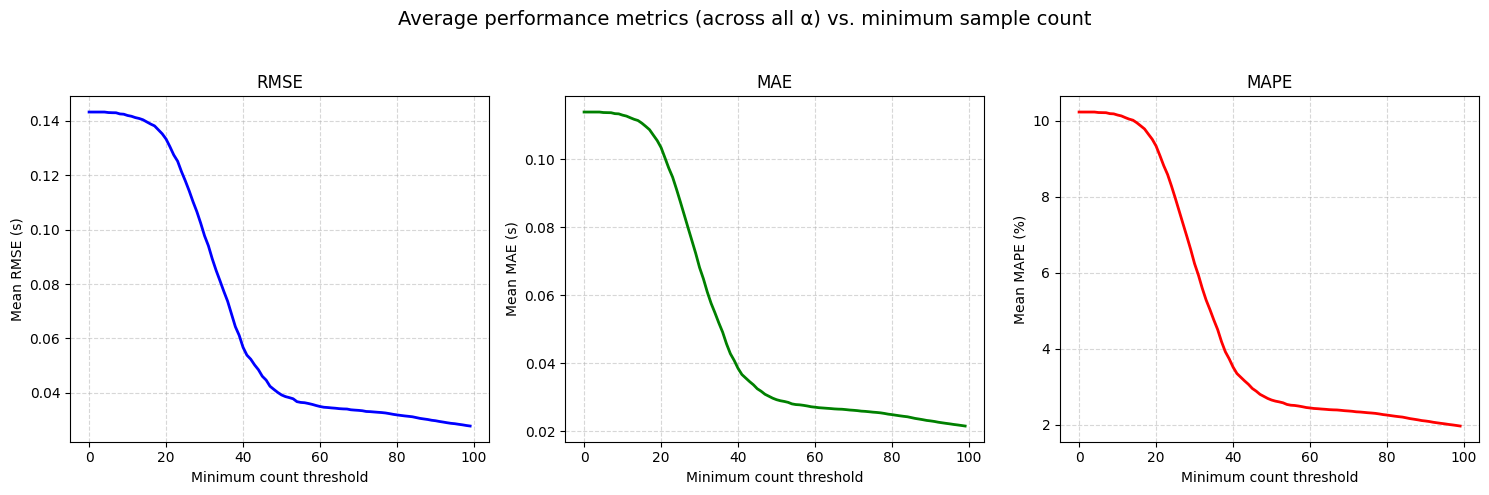

In [87]:
fig = plot_metrics_vs_mincount(results_d)

In [96]:
def plot_threshold_grid(
    results_df,          # contains columns: n, alpha, i, count, mu_eff
    experiment_data_df,  # raw data for empirical means (client_measured_time)
    state_df,            # per‑request data for confidence intervals (n, alpha, client_measured_time)
    fallback_mu,         # dict (n, alpha) -> service rate for fallback
    alpha=0.4,
    lam=0.3,
    thresholds=[0, 20, 40, 60, 80, 100],
    n_range=None,
    figsize=(15, 10),
    confidence_level=0.95
):
    # 1. Compute empirical confidence intervals (same for all subplots)
    df_alpha = state_df[state_df['alpha'] == alpha]
    emp_stats = df_alpha.groupby('n')['client_measured_time'].agg(
        mean='mean',
        std='std',
        count='size'
    ).reset_index()
    t_val = stats.t.ppf(1 - (1 - confidence_level)/2, emp_stats['count'] - 1)
    emp_stats['sem'] = emp_stats['std'] / np.sqrt(emp_stats['count'])
    emp_stats['ci_lower'] = emp_stats['mean'] - t_val * emp_stats['sem']
    emp_stats['ci_upper'] = emp_stats['mean'] + t_val * emp_stats['sem']
    emp_stats = emp_stats.sort_values('n')
    emp_n = emp_stats['n'].values
    emp_mean = emp_stats['mean'].values
    emp_lower = emp_stats['ci_lower'].values
    emp_upper = emp_stats['ci_upper'].values

    if n_range is None:
        n_range = sorted(emp_n)

    # Pre‑compute empirical means per (n, alpha)
    emp_means_full = experiment_data_df.groupby(['alpha', 'active_servers_num'])['client_measured_time'].mean()

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()

    all_metrics = []

    for idx, threshold in enumerate(thresholds):
        ax = axes[idx]

        # Filter states with count > threshold
        mask = results_df['count'] > threshold
        filtered = results_df[mask]
        mu_n_alpha_i = {
            (row['n'], row['alpha'], row['i']): row['mu_eff']
            for _, row in filtered.iterrows()
        }

        # Compute predictions
        T_pred = []
        for n in n_range:
            T = predict_T(
                n=n,
                alpha=alpha,
                lam=lam,
                mu_n_alpha_i=mu_n_alpha_i,
                fallback_mu_n_alpha=fallback_mu
            )
            T_pred.append(T)

        y_true = [emp_means_full.loc[(alpha, n)] for n in n_range]
        y_pred = T_pred

        # Compute metrics
        try:
            rmse, mae, mape = compare_results(y_true, y_pred)
            all_metrics.append((threshold, rmse, mae, mape))
            metrics_str = format_comparison((rmse, mae, mape), decimals=4)
        except Exception as e:
            metrics_str = f"Metrics error: {e}"

        # Plot
        ax.plot(emp_n, emp_mean, 'ko-', label='Empirical mean', markersize=2, linewidth=1.5)
        ax.fill_between(emp_n, emp_lower, emp_upper, color='gray', alpha=0.3,
                        label=f'{int(confidence_level*100)}% CI')
        ax.plot(n_range, T_pred, 'b-s', label=f'Prediction (min_count>{threshold})',
                markersize=2, linewidth=1.5, alpha=0.8)

        ax.set_xlabel('Number of servers (n)')
        ax.set_ylabel('Mean response time (s)')
        ax.set_title(f'min_count > {threshold}')
        ax.grid(True, linestyle='--', alpha=0.5)

        # Legend placed at bottom center
        ax.legend(fontsize=8, loc='lower center')

        # Metrics text box (still at top-left)
        ax.text(0.02, 0.98, metrics_str, transform=ax.transAxes,
                verticalalignment='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Overall title with average metrics
    if all_metrics:
        avg_rmse = np.mean([m[1] for m in all_metrics])
        avg_mae  = np.mean([m[2] for m in all_metrics])
        avg_mape = np.mean([m[3] for m in all_metrics])
        avg_str = format_comparison((avg_rmse, avg_mae, avg_mape), decimals=4)
        fig.suptitle(f'α = {alpha}  |  Average metrics across thresholds: {avg_str}', fontsize=14)
    else:
        fig.suptitle(f'α = {alpha}  |  No metrics computed', fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

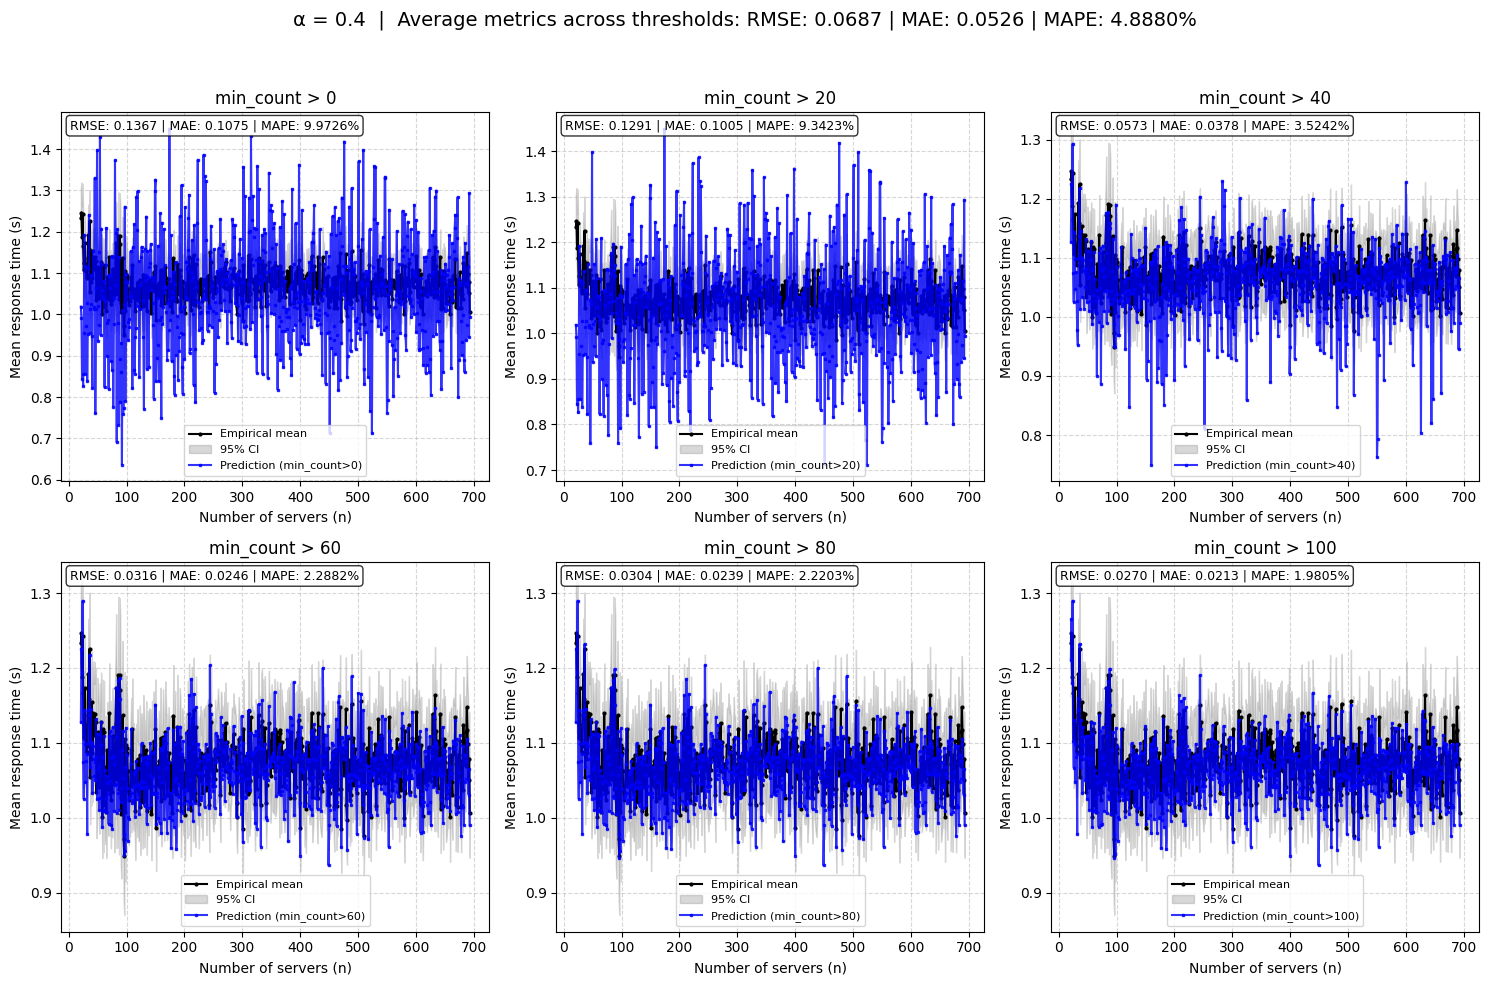

In [97]:
fig = plot_threshold_grid(
    results_df=results_df,          # from your state‑dependent processing
    experiment_data_df=experiment_data_df,
    state_df=state_df,
    fallback_mu=mu_n_alpha2,       # your simple fallback dictionary
    alpha=0.4,
    lam=LAMBDA,
    thresholds=[0, 20, 40, 60, 80, 100],
    n_range=list(range(21, 694))
)
plt.show()

In [67]:
assert 1==0, "Fix above"

AssertionError: Fix above

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_predicted_vs_processing(alpha, investigate_df, mu_n_alpha_i, lam=0.3,
                                 n_min=21, n_max=500, min_count=5):
    """
    Plot predicted total response time T against mean server processing time
    for a given alpha, over a range of n.

    Parameters
    ----------
    alpha : float
        The alpha value to filter.
    investigate_df : pd.DataFrame
        Aggregated DataFrame with columns:
            alpha, active_servers_num, server_processing_time_measured,
            client_measured_time (optional, for empirical T).
        It should contain the mean values for each (n, alpha).
    mu_n_alpha_i : dict
        State‑dependent rates with keys (n, alpha, i) -> μ.
    lam : float, optional
        Arrival rate (default 0.3).
    n_min, n_max : int, optional
        Range of n to plot (default 21–500).
    min_count : int, optional
        Minimum number of observations required for a state to be included.
        States with count < min_count are ignored and fallback is used.
    """
    # ------------------------------------------------------------------
    # 1. Prepare data from investigate_df for this alpha
    # ------------------------------------------------------------------
    df_alpha = investigate_df[investigate_df['alpha'] == alpha]
    # Create a mapping from n to mean server processing time (pure service)
    processing_time_dict = {}
    for _, row in df_alpha.iterrows():
        n = int(row['active_servers_num'])
        s_mean = row['server_processing_time_measured']
        if s_mean > 0:
            processing_time_dict[n] = s_mean

    # Also build a simple mu(n, alpha) from pure service for fallback
    mu_n_alpha = { (n, alpha): 1.0 / s_mean for n, s_mean in processing_time_dict.items() if s_mean > 0 }

    # Extend mu_n_alpha to all n up to n_max using saturation
    # (carry forward the last observed mu for this alpha)
    if mu_n_alpha:
        # Find the largest observed n for this alpha
        max_observed_n = max(n for (n, a) in mu_n_alpha.keys() if a == alpha)
        last_mu = mu_n_alpha[(max_observed_n, alpha)]
        for n in range(n_min, n_max + 1):
            if (n, alpha) not in mu_n_alpha:
                mu_n_alpha[(n, alpha)] = last_mu

    # ------------------------------------------------------------------
    # 2. Define the prediction function (using the same compute_T logic)
    # ------------------------------------------------------------------
    def predict_T_local(n, alpha):
        """Wrapper for predict_T with fallback to mu_n_alpha."""
        return predict_T(n=n, alpha=alpha, lam=LAMBDA, mu_n_alpha_i=mu_n_alpha_i, fallback_mu_n_alpha=mu_n_alpha)

    # ------------------------------------------------------------------
    # 3. Loop over n and collect data
    # ------------------------------------------------------------------
    n_values = list(range(n_min, n_max + 1))
    T_pred = []
    processing_times = []
    empirical_T = []  # optional, if client_measured_time exists

    for n in n_values:
        # Processing time (from investigate_df) – only if observed
        if n in processing_time_dict:
            processing_times.append(processing_time_dict[n])
        else:
            processing_times.append(np.nan)

        # Empirical total time if available (optional)
        emp_row = df_alpha[df_alpha['active_servers_num'] == n]
        if not emp_row.empty and 'client_measured_time' in df_alpha.columns:
            empirical_T.append(emp_row['client_measured_time'].iloc[0])
        else:
            empirical_T.append(np.nan)

        # Predicted T from the state‑dependent model
        # try:
        #     T_pred.append(predict_T_local(n, alpha))
        # except Exception as e:
        #     # If prediction fails (e.g., unstable), skip this n
        #     T_pred.append(np.nan)
        T_pred.append(predict_T_local(n, alpha))
        

    # ------------------------------------------------------------------
    # 4. Plot
    # ------------------------------------------------------------------
    plt.figure(figsize=(12, 6))

    # Plot processing time (pure service)
    # plt.plot(n_values, processing_times, 'g--', label='Mean server processing time', linewidth=2)

    # Plot predicted T
    plt.plot(n_values, T_pred, 'b-', label=f'Predicted T (state‑dep. model)', linewidth=2)

    # Optionally plot empirical T if available
    if any(not np.isnan(x) for x in empirical_T):
        plt.plot(n_values, empirical_T, 'ro', label='Empirical T (client_measured_time)', markersize=3)

    plt.xlabel('Number of servers (n)', fontsize=12)
    plt.ylabel('Time (seconds)', fontsize=12)
    plt.title(f'α = {alpha}, λ = {lam}\nPredicted total response time vs. pure processing time', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

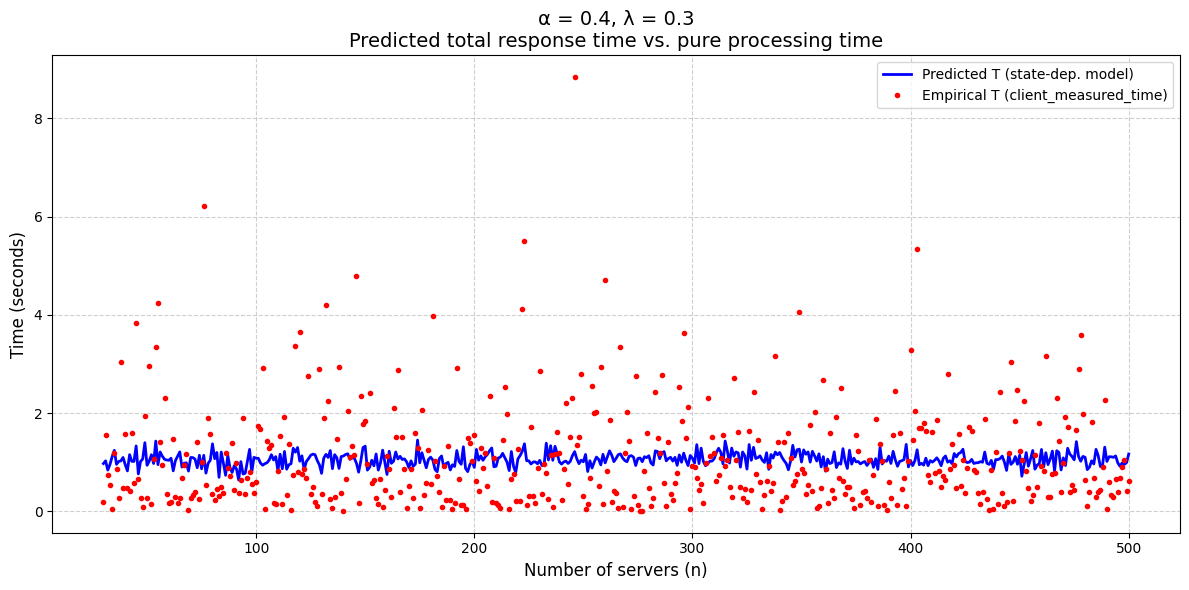

In [64]:
plot_predicted_vs_processing(alpha=0.4, investigate_df=experiment_data_df,
                             mu_n_alpha_i=mu_n_alpha_i, lam=0.3,
                             n_min=30, n_max=500)

In [ ]:
# -------- Extrapolators for state‑dependent μ(n,α,i) --------
def build_state_only_extrapolator(mu_d):
    state_rates = defaultdict(list)
    for (n, alpha, i), mu in mu_d.items():
        state_rates[(alpha, i)].append(mu)
    avg_rates = {key: np.mean(vals) for key, vals in state_rates.items()}
    global_mean = np.mean(list(mu_d.values()))
    def extrapolate(n, alpha, i):
        key = (alpha, i)
        return avg_rates.get(key, global_mean)
    return extrapolate

def build_saturation_extrapolator(mu_d):
    max_n_rates = {}
    for (n, alpha, i), mu in mu_d.items():
        key = (alpha, i)
        if key not in max_n_rates or n > max_n_rates[key][0]:
            max_n_rates[key] = (n, mu)
    global_mean = np.mean(list(mu_d.values()))
    def extrapolate(n, alpha, i):
        key = (alpha, i)
        if key in max_n_rates:
            return max_n_rates[key][1]
        else:
            return global_mean
    return extrapolate

def build_linear_extrapolator(mu_d, clamp_max=None):
    grouped = defaultdict(list)
    for (n, alpha, i), mu in mu_d.items():
        grouped[(alpha, i)].append((n, mu))
    models = {}
    global_mean = np.mean(list(mu_d.values()))
    for (alpha, i), points in grouped.items():
        points.sort()
        ns = np.array([p[0] for p in points])
        mus = np.array([p[1] for p in points])
        if len(points) >= 2:
            slope, intercept = np.polyfit(ns, mus, 1)
            models[(alpha, i)] = (slope, intercept)
        else:
            models[(alpha, i)] = (0.0, points[0][1])
    if clamp_max is None:
        clamp_max = max(mu_d.values())
    def extrapolate(n, alpha, i):
        key = (alpha, i)
        if key in models:
            slope, intercept = models[key]
            val = slope * n + intercept
            return max(0.1, min(val, clamp_max))
        else:
            return global_mean
    return extrapolate

# -------- State‑dependent compute_T with fallback --------
def compute_T(n, lam, alpha, mu_n_alpha_i, extrapolate_mu=None, fallback_mu_n_alpha=None):
    def get_mu(i):
        key = (n, alpha, i)
        if key in mu_n_alpha_i:
            return mu_n_alpha_i[key]
        if extrapolate_mu is not None:
            val = extrapolate_mu(n, alpha, i)
            if val is not None:
                return val
        if fallback_mu_n_alpha is not None:
            fb_key = (n, alpha)
            if fb_key in fallback_mu_n_alpha:
                return fallback_mu_n_alpha[fb_key]
        raise ValueError(f"Missing μ for n={n}, alpha={alpha}, i={i}")
        
    mu_vals = [get_mu(i) for i in range(1, n+1)]
    A = 1.0
    sum1 = 0.0
    sum_L1 = 0.0
    for k in range(1, n+1):
        mu_k = mu_vals[k-1]
        A = A * lam / (k * mu_k)
        sum1 += A
        sum_L1 += k * A
    A_n = A
    mu_n = mu_vals[n-1]
    denom = n * mu_n - lam
    if denom <= 0:
        raise ValueError(f"Unstable: n*μ_n - λ = {denom} ≤ 0")
    term_n1 = A_n * lam / denom
    p0 = 1.0 / (1.0 + sum1 + term_n1)
    factor = n * lam * A_n / denom
    term_L2 = factor * (1.0 + mu_n / denom)
    L = (sum_L1 + term_L2) * p0
    return L / lam

In [ ]:
def plot_all_methods(alpha, investigate_df, mu_d, lam=0.3, save_path=None):
    """
    Create subplots comparing each prediction method against empirical data.
    
    Parameters:
    - alpha: float, the alpha value to filter.
    - investigate_df: DataFrame with columns alpha, active_servers_num,
                      client_measured_time, server_processing_time_measured.
    - mu_d: dict with state‑dependent rates (n, alpha, i) -> μ.
    - lam: arrival rate (default 0.3).
    - save_path: optional path to save the figure.
    """
    # -------- 1. Compute all prediction curves --------
    # Extrapolators
    extrap_linear = build_linear_extrapolator(mu_d)
    extrap_sat = build_saturation_extrapolator(mu_d)
    extrap_state_only = build_state_only_extrapolator(mu_d)
    
    # Filter for given alpha
    df_alpha = investigate_df[investigate_df['alpha'] == alpha]
    n_values = sorted(df_alpha['active_servers_num'].unique())
    
    # Prepare data containers
    T_emp = []
    T_simple1 = []
    T_simple2 = []
    T_linear = []
    T_sat = []
    T_state_only = []
    
    for n in n_values:
        # Empirical
        emp_row = df_alpha[df_alpha['active_servers_num'] == n]
        T_emp.append(emp_row['client_measured_time'].iloc[0])
        
        # Simple 1
        mu = mu1.get((n, alpha))
        T_simple1.append(T_mmn(mu, lam, n) if mu is not None and not np.isnan(mu) else np.nan)
        
        # Simple 2
        mu = mu2.get((n, alpha))
        T_simple2.append(T_mmn(mu, lam, n) if mu is not None and not np.isnan(mu) else np.nan)
        
        # State‑dependent with linear extrapolation
        try:
            T_linear.append(compute_T(n, lam, alpha, mu_d, extrapolate_mu=extrap_linear))
        except Exception:
            T_linear.append(np.nan)
        
        # State‑dependent with saturation
        try:
            T_sat.append(compute_T(n, lam, alpha, mu_d, extrapolate_mu=extrap_sat))
        except Exception:
            T_sat.append(np.nan)
        
        # State‑dependent with state-only
        try:
            T_state_only.append(compute_T(n, lam, alpha, mu_d, extrapolate_mu=extrap_state_only))
        except Exception:
            T_state_only.append(np.nan)
    
    # -------- 2. Create subplots --------
    # We'll have 6 subplots: 5 methods + 1 combined overlay
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    # Flatten axes for easy indexing
    ax = axes.flatten()
    
    # Define method data and labels
    methods = [
        ('Simple M/M/n (μ from processing time)', T_simple1, 'r-s'),
        ('Simple M/M/n (Calibrated μ)', T_simple2, 'g-^'),
        ('State‑dep. (Linear extrapolation)', T_linear, 'b-d'),
        ('State‑dep. (Saturation extrapolation)', T_sat, 'c-p'),
        ('State‑dep. (State‑only extrapolation)', T_state_only, 'm-o')
    ]
    
    # Plot each method vs empirical in separate subplots
    for idx, (label, T_pred, style) in enumerate(methods):
        ax[idx].plot(n_values, T_emp, 'ko-', label='Empirical', markersize=4, linewidth=1.5)
        ax[idx].plot(n_values, T_pred, style, label=label, markersize=4, linewidth=1.5, alpha=0.7)
        ax[idx].set_xlabel('Number of servers (n)')
        ax[idx].set_ylabel('Mean response time T (s)')
        ax[idx].set_title(label, fontsize=9)
        ax[idx].grid(True, linestyle='--', alpha=0.5)
        ax[idx].legend(fontsize=8)
    
    # Combined overlay plot (all curves)
    ax[5].plot(n_values, T_emp, 'ko-', label='Empirical', markersize=4, linewidth=2)
    ax[5].plot(n_values, T_simple1, 'r-s', label='Simple 1', markersize=3, linewidth=1.2, alpha=0.7)
    ax[5].plot(n_values, T_simple2, 'g-^', label='Simple 2', markersize=3, linewidth=1.2, alpha=0.7)
    ax[5].plot(n_values, T_linear, 'b-d', label='Linear', markersize=3, linewidth=1.2, alpha=0.7)
    ax[5].plot(n_values, T_sat, 'c-p', label='Saturation', markersize=3, linewidth=1.2, alpha=0.7)
    ax[5].plot(n_values, T_state_only, 'm-o', label='State-only', markersize=3, linewidth=1.2, alpha=0.7)
    ax[5].set_xlabel('Number of servers (n)')
    ax[5].set_ylabel('Mean response time T (s)')
    ax[5].set_title('All methods combined', fontsize=10)
    ax[5].grid(True, linestyle='--', alpha=0.5)
    ax[5].legend(fontsize=8, loc='best')
    
    plt.suptitle(f'Comparison of μ estimation methods for α={alpha}, λ={lam}', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print('-'*50)
    if T_simple1:
        print(f"T_simple1 diff: {average_difference(T_emp, T_simple1):.6f}")
    if T_simple2:
        print(f"T_simple2 diff: {average_difference(T_emp, T_simple2):.6f}")
    if T_linear:
        print(f"T_linear diff: {average_difference(T_emp, T_linear):.6f}")
    if T_sat:
        print(f"T_sat diff: {average_difference(T_emp, T_sat):.6f}")
    if T_state_only:
        print(f"T_state_only diff: {average_difference(T_emp, T_state_only):.6f}")
    print('-'*50)

In [ ]:
# Assuming investigate_df and mu_d are already defined
plot_all_methods(alpha=0.4, investigate_df=investigate_df, mu_d=mu_n_alpha_i, lam=0.3, save_path='comparison.png')

In [ ]:
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import os

def plot_all_methods_with_ci(alpha, state_df, n_values,
                             confidence_level=0.95, save_dir=None,
                             show_combined=True, dpi=300):
    """
    Generate separate plots for each prediction method, each with empirical
    mean and confidence intervals. Optionally generate a combined plot.

    Parameters
    ----------
    alpha : float
        The alpha value to filter.
    state_df : pd.DataFrame
        Raw per‑request data with columns ['n', 'alpha', 'client_measured_time'].
    n_values : list of int
        The n values for which predictions are available.
    confidence_level : float, optional
        Confidence level for intervals (default 0.95).
    save_dir : str or None, optional
        If provided, saves each figure as PNG in this directory.
    show_combined : bool, optional
        If True, also create a figure with all methods overlaid.
    dpi : int, optional
        Resolution for saved figures.
    """
    # ------------------------------------------------------------------
    # 1. Compute empirical confidence intervals from state_df
    # ------------------------------------------------------------------
    df_alpha = state_df[state_df['alpha'] == alpha]
    emp_stats = df_alpha.groupby('n')['client_measured_time'].agg(
        mean='mean',
        std='std',
        count='size'
    ).reset_index()
    
    t_val = stats.t.ppf(1 - (1 - confidence_level)/2, emp_stats['count'] - 1)
    emp_stats['sem'] = emp_stats['std'] / np.sqrt(emp_stats['count'])
    emp_stats['ci_lower'] = emp_stats['mean'] - t_val * emp_stats['sem']
    emp_stats['ci_upper'] = emp_stats['mean'] + t_val * emp_stats['sem']
    emp_stats = emp_stats.sort_values('n')
    
    emp_n = emp_stats['n'].values
    emp_mean = emp_stats['mean'].values
    emp_lower = emp_stats['ci_lower'].values
    emp_upper = emp_stats['ci_upper'].values

    # ------------------------------------------------------------------
    # 2. Compute all predictions (using your existing code)
    # ------------------------------------------------------------------  
    extrap_linear = build_linear_extrapolator(mu_n_alpha_i)
    extrap_sat = build_saturation_extrapolator(mu_n_alpha_i)
    extrap_state_only = build_state_only_extrapolator(mu_n_alpha_i)
    
    T_simple1, T_simple2, T_linear, T_sat, T_state_only = [], [], [], [], []
    
    for n in n_values:
        mu = mu1.get((n, alpha))
        T_simple1.append(T_mmn(mu, LAMBDA, n) if mu is not None and not np.isnan(mu) else np.nan)
        
        mu = mu2.get((n, alpha))
        T_simple2.append(T_mmn(mu, LAMBDA, n) if mu is not None and not np.isnan(mu) else np.nan)
        
        try:
            T_linear.append(compute_T(n, LAMBDA, alpha, mu_n_alpha_i, extrapolate_mu=extrap_linear))
        except Exception:
            T_linear.append(np.nan)
        
        try:
            T_sat.append(compute_T(n, LAMBDA, alpha, mu_n_alpha_i, extrapolate_mu=extrap_sat))
        except Exception:
            T_sat.append(np.nan)
        
        try:
            T_state_only.append(compute_T(n, LAMBDA, alpha, mu_n_alpha_i, extrapolate_mu=extrap_state_only))
        except Exception:
            T_state_only.append(np.nan)
    
    # Align predictions with emp_n
    def align_predictions(pred_list):
        n_to_pred = dict(zip(n_values, pred_list))
        return np.array([n_to_pred.get(n, np.nan) for n in emp_n], dtype=float)
    
    predictions = {
        'Simple 1 (processing time)': align_predictions(T_simple1),
        'Simple 2 (calibrated)': align_predictions(T_simple2),
        'State‑dep. (linear)': align_predictions(T_linear),
        'State‑dep. (saturation)': align_predictions(T_sat),
        'State‑dep. (state‑only)': align_predictions(T_state_only)
    }
    
    method_styles = [
        ('Simple 1 (processing time)', 'r-s'),
        ('Simple 2 (calibrated)', 'g-^'),
        ('State‑dep. (linear)', 'b-d'),
        ('State‑dep. (saturation)', 'c-p'),
        ('State‑dep. (state‑only)', 'm-o')
    ]
    
    # ------------------------------------------------------------------
    # 3. Generate separate figures for each method
    # ------------------------------------------------------------------
    if save_dir and not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    for name, style in method_styles:
        fig, ax = plt.subplots(figsize=(10, 6))
        pred = predictions[name]
        
        # Empirical mean
        ax.plot(emp_n, emp_mean, 'ko-', label='Empirical mean', markersize=5, linewidth=2)
        # Confidence band
        ax.fill_between(emp_n, emp_lower, emp_upper, color='gray', alpha=0.3,
                        label=f'{int(confidence_level*100)}% CI')
        # Prediction
        ax.plot(emp_n, pred, style, label=name, markersize=5, linewidth=2, alpha=0.7)
        
        ax.set_xlabel('Number of servers (n)', fontsize=12)
        ax.set_ylabel('Mean response time (s)', fontsize=12)
        ax.set_title(f'{name}  (α = {alpha})', fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=10)
        
        if save_dir:
            # Create a safe filename
            fname = name.replace(' ', '_').replace('(', '').replace(')', '').replace('.', '').replace('‑', '-')
            fname = fname + '.png'
            plt.savefig(os.path.join(save_dir, fname), dpi=dpi, bbox_inches='tight')
            plt.close(fig)
        else:
            plt.show()
    
    # ------------------------------------------------------------------
    # 4. Optional combined plot
    # ------------------------------------------------------------------
    if show_combined:
        fig, ax = plt.subplots(figsize=(12, 7))
        ax.plot(emp_n, emp_mean, 'ko-', label='Empirical mean', markersize=5, linewidth=2)
        ax.fill_between(emp_n, emp_lower, emp_upper, color='gray', alpha=0.2,
                        label=f'{int(confidence_level*100)}% CI')
        
        for name, style in method_styles:
            pred = predictions[name]
            ax.plot(emp_n, pred, style, label=name, markersize=4, linewidth=1.5, alpha=0.7)
        
        ax.set_xlabel('Number of servers (n)', fontsize=12)
        ax.set_ylabel('Mean response time (s)', fontsize=12)
        ax.set_title(f'All methods combined  (α = {alpha})', fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=9, loc='best')
        
        if save_dir:
            plt.savefig(os.path.join(save_dir, 'combined.png'), dpi=dpi, bbox_inches='tight')
            plt.close(fig)
        else:
            plt.show()

In [ ]:
n_values = range(21, 694)
plot_all_methods_with_ci(
    alpha=0.4,
    state_df=state_df,
    n_values=n_values,
    confidence_level=0.95,
    # save_dir='plots',  # Uncomment to save 
    show_combined=False,
    dpi=300
)